In [1]:
import utils
# 2 ways to force a reload of module
# 1. restart kernel -> run all cells
# 2. use the importlib module
import importlib
importlib.reload(utils)

utils.say_hello()

hello!!!!!!🐟🐟🐟🐟🐟🐟🐟🐟🐟🐟🐟🤌🏿🤌🏿🤌🏿🤌🏿


Recall: we can said a dataset is from the "universe of instances"

In stats, a dataset is a sample from a population
* dataset = sample
* universe = population

Example:
* Sample: the number of emails did 222 students receive in February 2022
* Population: the number of emails all college students nation-wide (world-wide) receive in February 2022
    * Really expensive to collect (time and money)

Some other stats terms to know
* Parameter: any measurable characteristic about a *population*
    * E.g. Population mean $\mu$
* Statistic: any measurable characteristic about a *sample*
    * E.g. Sample mean $\overline{x}$
* Descriptive statistics: organizing, summarizing, or presenting data in an informative way
    * E.g. central tendencies, data dispersion, charting, ...
* Inferential statistics: making inferences that go beyond known data
    * E.g. hypothesis testing, making predictions from linear regression, machine learning, ...

Summary stat: summarizes data into a single or set of values. Examples:

Number of instances

In [18]:
# we need some data
import pandas as pd

x = [1, 1, 1, 4, 1, 11, 2, 8]
x_ser = pd.Series(x)
print(x_ser)
print("Number of instances:", len(x_ser), x_ser.shape)

0     1
1     1
2     1
3     4
4     1
5    11
6     2
7     8
dtype: int64
Number of instances: 8 (8,)


Min and max values
* Don't really make sense for nominal attributes

In [3]:
print("min:", x_ser.min(), "max:", x_ser.max())

min: 1 max: 11


## Central Tendency Measures
Central tendency measures represent the middle values of a distribution of values
* Mean
* Median
* Mode
* Mid-value

TODO: Calculate the above with our `x_ser`, then we will do data dispersion measures, then we will talk about normal distributions

Mid-value: $\frac{min + max}{2}$

In [4]:
print("mid-value:", (x_ser.min() + x_ser.max()) / 2)

mid-value: 6.0


Arithmetic mean (AKA average):
* Sensitive to outliers
* Really to apply when you know your data is numeric

In [5]:
print("mean:", x_ser.mean())

mean: 3.625


Median: the middle value in a sorted list of values
* If the number of values is even, then take is the mid point between the two middle numbers

In [7]:
print(x_ser.sort_values())
print("median:", x_ser.median())

0     1
1     1
2     1
4     1
6     2
3     4
7     8
5    11
dtype: int64
median: 1.5


Mode: the most frequently occuring value(s)

In [13]:
print("mode:\n", x_ser.mode(), sep="")
x2 = [1, 1, 1, 4, 4, 11, 4, 8]
x_ser2 = pd.Series(x2)
print("mode:\n", x_ser2.mode(), sep="")
print(x_ser2.mode().index)

mode:
0    1
dtype: int64
mode:
0    1
1    4
dtype: int64
RangeIndex(start=0, stop=2, step=1)


## Data Dispersion (Spread)
Range: max - min

In [14]:
print("range:", x_ser.max() - x_ser.min())

range: 10


Quantiles: Roughly equal-sized partitions of the data (in sorted order)
* 2-quantiles: 1 data point that divides the dataset into 2 halves (AKA median)
* Quartiles: 3 data points that divide the dataset into 4 quarters
* Percentiles: 99 data points that divide the dataset into 100 groups
    * 25th percentile: 1st quartile
    * 50th percentile: 2nd quartile: median
    * 75th percentile: 3rd quartile
* IQR (interquartile range): 75th percentile - 25th percentile

In [17]:
x_ser_sorted = x_ser.sort_values()
print(x_ser_sorted)
print("75th percentile:", x_ser_sorted.quantile([0.75]))
# lets say we need a data point that is in the list of values
index = round(0.75 * len(x_ser_sorted))
print("75th percentile:", x_ser_sorted.iloc[index])
# 8 is the value in the series such that
# 75% of values is less than it

0     1
1     1
2     1
4     1
6     2
3     4
7     8
5    11
dtype: int64
75th percentile: 0.75    5.0
dtype: float64
75th percentile: 8


## Box Plots
Are great visualizations for the spread of data
* Non-parametric

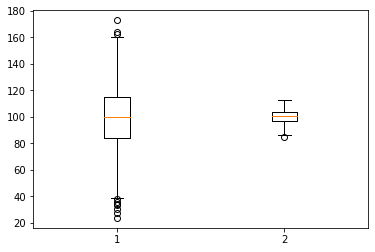

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# we need some random data
# let's do "normal" data
mean = 100
stdev = 25
num_samples = 1000
x1 = np.random.normal(mean, stdev, num_samples)
stdev = 5
num_samples = 100
x2 = np.random.normal(mean, stdev, num_samples)

# the horizontal orange line in the box is the median
# the box is the IQR
# the whiskers (AKA lines) extending from the box are +/- 1.5 * IQR
# the circles are outliers

plt.boxplot([x1, x2])
plt.show()

Variance: measures the spread of data from the mean
* High variance: the data is more spread out
* Low variance: the data is more clustered

Standard deviation: square root of variance
* More commonly used... same units as the mean

In [21]:
print("variance:", x_ser.var())
print("standard deviation:", x_ser.std(), np.sqrt(x_ser.var()))

variance: 14.839285714285714
standard deviation: 3.8521793460696654 3.8521793460696654


## Histogram Demo
Let's see the effects of the standard deviation on shape of data distributions

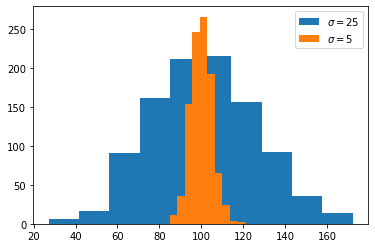

In [31]:
mean = 100
stdev = 25
num_samples = 1000
x1 = np.random.normal(mean, stdev, num_samples)
stdev = 5
x2 = np.random.normal(mean, stdev, num_samples)

plt.hist(x1, label="$\sigma=25$")
plt.hist(x2, label="$\sigma=5$")
plt.legend()
plt.show()

## Empirical Rule for Normal Distributions
If your data is "normal" then:
* 68% of data are within mean +/- 1 standard deviation
* 95% of data are within mean +/- 2 standard deviations
* 99.7% of data are within mean +/- 3 standard deviations

Let's "prove" this for our x1 sampled data

In [32]:
count_1stdev = 0
count_2stdev = 0
count_3stdev = 0

sampled_mean = x1.mean()
sampled_stdev = x1.std()

for value in x1:
    if sampled_mean - 1 * sampled_stdev <= value\
        <= sampled_mean + 1 * sampled_stdev:
        count_1stdev += 1
    if sampled_mean - 2 * sampled_stdev <= value\
        <= sampled_mean + 2 * sampled_stdev:
        count_2stdev += 1
    if sampled_mean - 3 * sampled_stdev <= value\
        <= sampled_mean + 3 * sampled_stdev:
        count_3stdev += 1

print("within +/- 1:", count_1stdev / num_samples * 100, "%")
print("within +/- 2:", count_2stdev / num_samples * 100, "%")
print("within +/- 3:", count_3stdev / num_samples * 100, "%")

within +/- 1: 66.60000000000001 %
within +/- 2: 95.8 %
within +/- 3: 100.0 %
